# Regressão Logística — Efeitos dos atributos via AME

Este notebook mensura o impacto de cada atributo no desfecho do sinistro (`gravidade`) usando os **Efeitos Marginais Médios (AME)** como medida de efeito.

O AME é definido como:
$$AME_k = E\left[\frac{\partial P(Y=1 | X)}{\partial x_k}\right]$$

Ele expressa a **variação média na probabilidade prevista** do evento associada a uma variação unitária em x_k — a mesma escala e interpretação do `SHAP_global_E[φ_k]` calculado nos demais modelos.

**Importante:** este notebook usa **exatamente as mesmas colunas** da base tratada utilizada por Random Forest, XGBoost e CatBoost, garantindo comparabilidade direta dos resultados.

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
url = "../../database/completo/df_completo_01_uf_br.csv"
df = pd.read_csv(url, sep=",", encoding="UTF-8")

In [5]:
df.condicao_metereologica.value_counts()

condicao_metereologica
0.000000    427854
0.333333    104583
0.666667     92245
1.000000      6475
Name: count, dtype: int64

In [3]:
train_df = df[(df["ano"] >= 2017) & (df["ano"] <= 2024)]
test_df  = df[df["ano"] == 2025]

X_train = train_df.drop(columns=["gravidade", "ano"])
y_train = train_df["gravidade"]

X_test = test_df.drop(columns=["gravidade", "ano"])
y_test = test_df["gravidade"]

print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")
print(f"Colunas: {list(X_train.columns)}")

Treino: (558847, 16) | Teste: (72310, 16)
Colunas: ['dia_semana', 'km', 'sentido_via', 'condicao_metereologica', 'tipo_pista', 'uso_solo', 'intersecao_de_vias', 'reta', 'declive', 'feriado', 'turno', 'mes', 'vel_max', 'distancia_radar_m', 'total_ocorrencia', 'uf_br']


In [4]:
# ============================================================
# TREINAMENTO — Regressão Logística via statsmodels
# ============================================================
# statsmodels fornece get_margeff() para calcular os AMEs
# analiticamente.
#
# Desbalanceamento: peso inverso da frequência de cada classe,
# equivalente ao class_weight='balanced' dos demais modelos.

n_neg   = (y_train == 0).sum()
n_pos   = (y_train == 1).sum()
n_total = len(y_train)

pesos = y_train.map({
    0: n_total / (2 * n_neg),
    1: n_total / (2 * n_pos)
})

print(f"Desbalanceamento -- negativos: {n_neg:,} | positivos: {n_pos:,}")
print(f"Peso classe 0: {n_total / (2 * n_neg):.4f}")
print(f"Peso classe 1: {n_total / (2 * n_pos):.4f}")

X_train_const = sm.add_constant(X_train)

modelo = sm.Logit(y_train, X_train_const, freq_weights=pesos)
resultado_fit = modelo.fit(method="bfgs", maxiter=500, disp=False)

print("\nModelo treinado.")
print(f"Pseudo R2 de McFadden: {resultado_fit.prsquared:.4f}")
print(f"Log-likelihood: {resultado_fit.llf:.2f}")

Desbalanceamento -- negativos: 486,401 | positivos: 72,446
Peso classe 0: 0.5745
Peso classe 1: 3.8570

Modelo treinado.
Pseudo R2 de McFadden: 0.0211
Log-likelihood: -211000.42


In [5]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

X_test_const = sm.add_constant(X_test, has_constant='add')

y_prob = resultado_fit.predict(X_test_const)
y_pred = (y_prob >= 0.5).astype(int)

print("\n=== Metricas (Teste 2025) ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")
print(f"AUC      : {roc_auc_score(y_test, y_prob):.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))


=== Metricas (Teste 2025) ===
Accuracy : 0.8589
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000
AUC      : 0.6029

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.86      1.00      0.92     62109
           1       0.00      0.00      0.00     10201

    accuracy                           0.86     72310
   macro avg       0.43      0.50      0.46     72310
weighted avg       0.74      0.86      0.79     72310



In [6]:
# ============================================================
# EFEITOS MARGINAIS MEDIOS (AME)
# ============================================================
# get_margeff() calcula para cada observacao i:
#   dP/dxk(i) = beta_k * P_hat(i) * (1 - P_hat(i))
# e retorna a media sobre todas as observacoes:
#   AME_k = E[dP/dxk]
#
# Isso e o analogo exato ao SHAP_global_E[phi_k]:
# variacao media em P(gravidade=1) atribuida a variavel k,
# na escala de probabilidade.
#
# at='overall' -> media sobre todas as observacoes de treino
# method='dydx' -> derivada parcial continua

margeff = resultado_fit.get_margeff(at='overall', method='dydx')

ame_df = pd.DataFrame({
    "AME":         margeff.margeff,
    "Erro_padrao": margeff.margeff_se,
    "p_valor":     margeff.pvalues,
    "IC_95_inf":   margeff.conf_int()[:, 0],
    "IC_95_sup":   margeff.conf_int()[:, 1],
}, index=X_train.columns)

# AME_abs: importancia absoluta -- analogo ao SHAP_importancia_E[|phi_k|]
ame_df["AME_abs"]       = ame_df["AME"].abs()
ame_df["significativo"] = ame_df["p_valor"] < 0.05
ame_df = ame_df.sort_values(by="AME_abs", ascending=False)

# ============================================================
# SAIDA NO MESMO FORMATO DO SHAP
# ============================================================
# Reproduz exatamente a estrutura das tabelas SHAP dos demais
# modelos para facilitar a comparacao direta.

resultado = ame_df[["AME", "AME_abs"]].copy()
resultado.columns = ["AME_global_E[dP/dxk]", "AME_importancia_E[|dP/dxk|]"]

print("\n=== Impacto dos atributos na probabilidade do desfecho (Regressao Logistica) ===")
print("AME_global_E[dP/dxk]        -> efeito medio com sinal, em unidades de probabilidade")
print("AME_importancia_E[|dP/dxk|] -> importancia absoluta, para ranqueamento")
print()
print(resultado.to_string())


=== Impacto dos atributos na probabilidade do desfecho (Regressao Logistica) ===
AME_global_E[dP/dxk]        -> efeito medio com sinal, em unidades de probabilidade
AME_importancia_E[|dP/dxk|] -> importancia absoluta, para ranqueamento

                        AME_global_E[dP/dxk]  AME_importancia_E[|dP/dxk|]
total_ocorrencia                   -0.161725                     0.161725
tipo_pista                          0.071600                     0.071600
distancia_radar_m                   0.057057                     0.057057
vel_max                             0.040427                     0.040427
condicao_metereologica             -0.039369                     0.039369
uf_br                              -0.031975                     0.031975
dia_semana                          0.026129                     0.026129
declive                             0.016871                     0.016871
intersecao_de_vias                 -0.016648                     0.016648
uso_solo              

In [7]:
# ============================================================
# SIGNIFICANCIA ESTATISTICA
# ============================================================
# Vantagem do AME sobre o SHAP: acompanha erro padrao e
# p-valor, permitindo testar se o efeito e estatisticamente
# diferente de zero.

print("\n=== Significancia dos AMEs (alpha = 0.05) ===")
print(f"{'Variavel':35s}  {'AME':>9}  {'p-valor':>9}  {'Sig':>5}")
print("-" * 65)

for var, row in ame_df.iterrows():
    sig = "*" if row["p_valor"] < 0.05 else ""
    print(f"{var:35s}  {row['AME']:>+9.4f}  {row['p_valor']:>9.4f}  {sig:>5}")

print("\n* p-valor < 0.05")


=== Significancia dos AMEs (alpha = 0.05) ===
Variavel                                   AME    p-valor    Sig
-----------------------------------------------------------------
total_ocorrencia                       -0.1617     0.0000      *
tipo_pista                             +0.0716     0.0000      *
distancia_radar_m                      +0.0571     0.0000      *
vel_max                                +0.0404     0.0000      *
condicao_metereologica                 -0.0394     0.0000      *
uf_br                                  -0.0320     0.0000      *
dia_semana                             +0.0261     0.0000      *
declive                                +0.0169     0.0000      *
intersecao_de_vias                     -0.0166     0.0000      *
uso_solo                               -0.0126     0.0000      *
mes                                    +0.0102     0.0000      *
km                                     -0.0062     0.0408      *
reta                                   -0.

In [8]:
# ============================================================
# INTERPRETACAO DOS EFEITOS
# ============================================================
print("\n=== Interpretacao dos efeitos ===")
print("Variacao media em P(gravidade=1) atribuida a cada variavel.\n")

for var, row in ame_df.iterrows():
    ame     = row["AME"]
    ame_abs = row["AME_abs"]
    sig     = "*" if row["significativo"] else ""

    if ame_abs < 1e-8:
        print(f"{var:35s}: SEM EFEITO")
    elif ame > 0:
        print(f"{var:35s}: AUMENTA a probabilidade em +{ame:.4f} (em media) {sig}")
    else:
        print(f"{var:35s}: REDUZ  a probabilidade em {ame:.4f} (em media) {sig}")

print("\n* p-valor < 0.05")


=== Interpretacao dos efeitos ===
Variacao media em P(gravidade=1) atribuida a cada variavel.

total_ocorrencia                   : REDUZ  a probabilidade em -0.1617 (em media) *
tipo_pista                         : AUMENTA a probabilidade em +0.0716 (em media) *
distancia_radar_m                  : AUMENTA a probabilidade em +0.0571 (em media) *
vel_max                            : AUMENTA a probabilidade em +0.0404 (em media) *
condicao_metereologica             : REDUZ  a probabilidade em -0.0394 (em media) *
uf_br                              : REDUZ  a probabilidade em -0.0320 (em media) *
dia_semana                         : AUMENTA a probabilidade em +0.0261 (em media) *
declive                            : AUMENTA a probabilidade em +0.0169 (em media) *
intersecao_de_vias                 : REDUZ  a probabilidade em -0.0166 (em media) *
uso_solo                           : REDUZ  a probabilidade em -0.0126 (em media) *
mes                                : AUMENTA a probabilidad

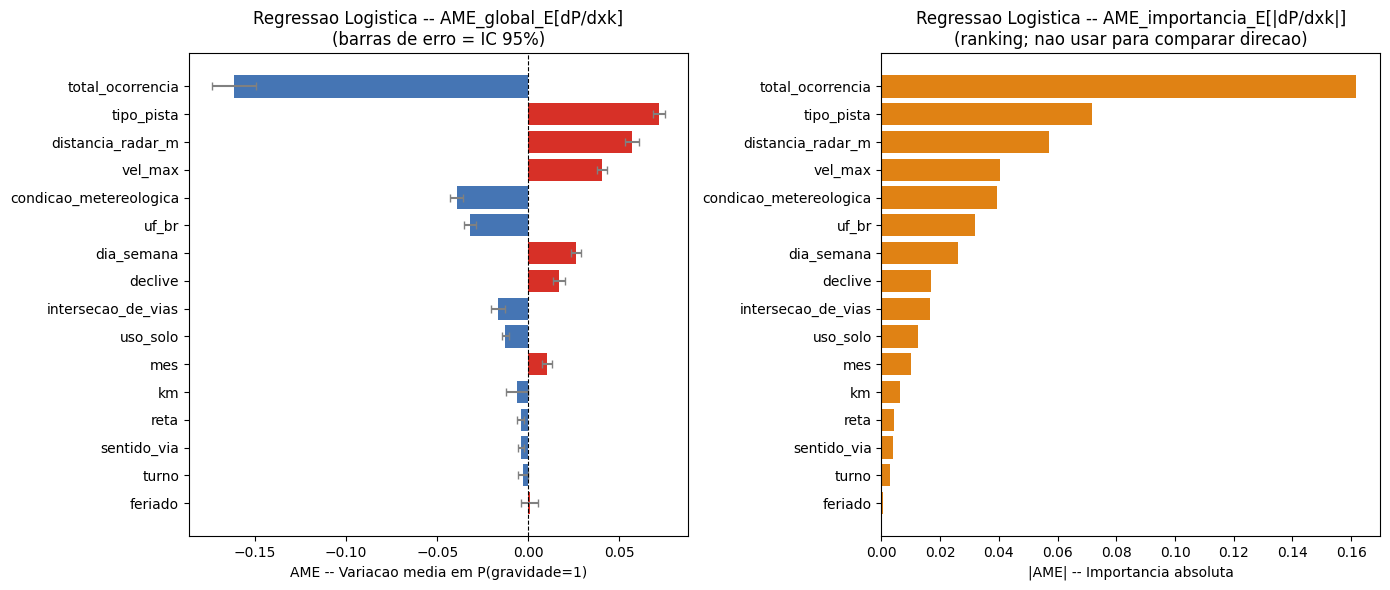

Grafico salvo em logit_ame_efeitos.png


In [9]:
# ============================================================
# VISUALIZACOES — mesmo layout dos graficos SHAP
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Grafico 1: AME com sinal e IC 95% (analogo ao SHAP_global)
cores = ['#d73027' if v > 0 else '#4575b4' for v in ame_df["AME"]]
yerr_low  = ame_df["AME"] - ame_df["IC_95_inf"]
yerr_high = ame_df["IC_95_sup"] - ame_df["AME"]

axes[0].barh(
    ame_df.index, ame_df["AME"],
    xerr=[yerr_low, yerr_high],
    color=cores, ecolor='gray', capsize=3
)
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel("AME -- Variacao media em P(gravidade=1)")
axes[0].set_title("Regressao Logistica -- AME_global_E[dP/dxk]\n(barras de erro = IC 95%)")
axes[0].invert_yaxis()

# Grafico 2: importancia absoluta (analogo ao SHAP_importancia)
axes[1].barh(ame_df.index, ame_df["AME_abs"], color='#e08214')
axes[1].set_xlabel("|AME| -- Importancia absoluta")
axes[1].set_title("Regressao Logistica -- AME_importancia_E[|dP/dxk|]\n(ranking; nao usar para comparar direcao)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("logit_ame_efeitos.png", dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvo em logit_ame_efeitos.png")

In [10]:
# ============================================================
# EXPORTACAO — mesmo formato das tabelas SHAP
# ============================================================
# Salva em CSV com as mesmas colunas usadas nas tabelas SHAP
# dos demais modelos para facilitar a comparacao entre modelos.

tabela_export = ame_df[["AME", "AME_abs", "p_valor", "IC_95_inf", "IC_95_sup"]].copy()
tabela_export.columns = [
    "SHAP_global_E[phi_k]",         # mesmo nome das tabelas SHAP
    "SHAP_importancia_E[|phi_k|]",  # mesmo nome das tabelas SHAP
    "p_valor",
    "IC_95_inf",
    "IC_95_sup"
]

print("\n=== Tabela no formato SHAP para comparacao entre modelos ===")
print("(colunas nomeadas igual aos demais modelos)\n")
print(tabela_export[["SHAP_global_E[phi_k]", "SHAP_importancia_E[|phi_k|]"]].to_string())

tabela_export.to_csv("logit_ames.csv")
print("\nSalvo em logit_ames.csv")


=== Tabela no formato SHAP para comparacao entre modelos ===
(colunas nomeadas igual aos demais modelos)

                        SHAP_global_E[phi_k]  SHAP_importancia_E[|phi_k|]
total_ocorrencia                   -0.161725                     0.161725
tipo_pista                          0.071600                     0.071600
distancia_radar_m                   0.057057                     0.057057
vel_max                             0.040427                     0.040427
condicao_metereologica             -0.039369                     0.039369
uf_br                              -0.031975                     0.031975
dia_semana                          0.026129                     0.026129
declive                             0.016871                     0.016871
intersecao_de_vias                 -0.016648                     0.016648
uso_solo                           -0.012599                     0.012599
mes                                 0.010193                     0.010193
km   

In [11]:
# ============================================================
# SUMARIO COMPLETO DO MODELO
# ============================================================
print(resultado_fit.summary2())

                            Results: Logit
Model:                 Logit             Pseudo R-squared:  0.021      
Dependent Variable:    gravidade         AIC:               422034.8475
Date:                  2026-04-13 16:15  BIC:               422225.8192
No. Observations:      558847            Log-Likelihood:    -2.1100e+05
Df Model:              16                LL-Null:           -2.1554e+05
Df Residuals:          558830            LLR p-value:       0.0000     
Converged:             1.0000            Scale:             1.0000     
Method:                MLE                                             
-----------------------------------------------------------------------
                        Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-----------------------------------------------------------------------
const                  -2.5222   0.0277 -91.2068 0.0000 -2.5764 -2.4680
dia_semana              0.2353   0.0120  19.6663 0.0000  0.2119  0.2588
km                   